
# Basic Text Mining

# Table of Contents

1. [Import data and representation](#1-representation)  
   1.1 [Predictive modeling](#11-Predictive-modeling)  

#### *Colab Notebook [Open in Colab](https://colab.research.google.com/drive/1Tyonydw0cblhSr1ygtrZH9IqdP1MP2xy?usp=share_link)*
#### *Useful information about [Basic Text Mining in R](https://yanyudm.github.io/Data-Mining-R/lecture/Basic_Text_Mining.html)*




#1 Import Libraries and Environment Setup

We begin by installing and importing all required Python libraries.

These libraries support:
- **Data manipulation** (`pandas`, `numpy`)
- **Text processing** (`re`, `nltk`)
- **Feature extraction** (`CountVectorizer`, `TfidfVectorizer`)
- **Machine learning models** (`scikit-learn`)
- **Visualization** (`matplotlib`, `wordcloud`)

The `nltk` stopword list is downloaded once and reused across the notebook.


In [22]:
# ============================================================
# Complete Google Colab Python Code
# Movie Reviews Sentiment (Python sklearn conversion)
# Uses:
#  - movie_reviews.csv
#  - negative-words.txt
#  - positive-words.txt
# ============================================================


In [23]:
import warnings
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    module=r"jupyter_client(\..*)?$",
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r".*utcnow\(\) is deprecated.*",
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r".*utcnow\(\) is deprecated.*",
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r".*scipy\.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated.*",
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r".*scipy\.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated.*",
    module=r"sklearn\.linear_model\._logistic",
)



In [24]:
# ----------------------------
# 0) Install + imports
# ----------------------------
!pip -q install pandas numpy scipy scikit-learn nltk wordcloud matplotlib requests

import pandas as pd
import numpy as np
import re
import requests
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from wordcloud import WordCloud
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

nltk.download("stopwords", quiet=True)

True

In [25]:
# ----------------------------
# 1) Load dataset
# ----------------------------
DATA_URL = "https://raw.githubusercontent.com/jonathanatuscpsu/DM-python/gh-pages/movie_reviews.csv"
reviews = pd.read_csv(DATA_URL, index_col=0)  # row.names=1 -> index_col=0

# Expect columns: content, polarity
TEXT_COL = "content"
TARGET_COL = "polarity"

print("Dataset shape:", reviews.shape)
print("Columns:", list(reviews.columns))
display(reviews.head())



Dataset shape: (2000, 2)
Columns: ['content', 'polarity']


,content,polarity
reviewid,,
cv000_29416.txt,"plot : two teen couples go to a church party ,...",0
cv001_19502.txt,the happy bastard's quick movie review damn th...,0
cv002_17424.txt,it is movies like these that make a jaded movi...,0
cv003_12683.txt,""" quest for camelot "" is warner bros . ' firs...",0
cv004_12641.txt,synopsis : a mentally unstable man undergoing ...,0


## Load the Movie Review Dataset

The dataset is loaded directly from GitHub using a raw file URL.

Each row represents a movie review and contains:
- `content`: the review text
- `polarity`: sentiment label  
  - 0 = negative  
  - 1 = positive

The first column is treated as an index to match the dataset’s original structure.


## Text Preprocessing and Corpus Creation

Raw text must be cleaned before numerical analysis.

For each review, we apply the following preprocessing steps:
1. Convert all text to lowercase
2. Remove numeric characters
3. Remove punctuation
4. Remove common English stopwords
5. Remove extra whitespace

The output is a **cleaned corpus**, stored as a Python list of strings.
Each element in the list corresponds to one cleaned review.


In [26]:

# ----------------------------
# 2) Build corpus + preprocessing
#    1) lower
#    2) remove numbers
#    3) remove punctuation + stopwords (+ "the","and")
#    4) strip whitespace
# ----------------------------
stop_words = set(stopwords.words("english")) | {"the", "and"}

def clean_text(s: str) -> str:
    s = str(s).lower()                         # tolower
    s = re.sub(r"\d+", " ", s)                 # removeNumbers
    s = re.sub(r"[^\w\s]", " ", s)             # removePunctuation
    tokens = [t for t in s.split() if t not in stop_words]
    s = " ".join(tokens)
    s = re.sub(r"\s+", " ", s).strip()         # stripWhitespace
    return s

corpus_clean = [clean_text(x) for x in reviews[TEXT_COL].astype(str)]

print("\nFirst cleaned review (preview):")
print(corpus_clean[0][:800], "...")


First cleaned review (preview):
plot two teen couples go church party drink drive get accident one guys dies girlfriend continues see life nightmares deal watch movie sorta find critique mind fuck movie teen generation touches cool idea presents bad package makes review even harder one write since generally applaud films attempt break mold mess head lost highway memento good bad ways making types films folks snag one correctly seem taken pretty neat concept executed terribly problems movie well main problem simply jumbled starts normal downshifts fantasy world audience member idea going dreams characters coming back dead others look like dead strange apparitions disappearances looooot chase scenes tons weird things happen simply explained personally mind trying unravel film every give clue get kind fed film biggest probl ...


## Term Frequency (TF) Representation

To convert text into numerical form, we use a **Term Frequency (TF)** representation.

This creates a matrix where:
- Rows represent documents (reviews)
- Columns represent unique words
- Values represent how often each word appears in a document

This matrix allows us to analyze and model text using standard machine-learning algorithms.


In [27]:
# ----------------------------
# 3) DTM (term frequency)
# ----------------------------
cv_full = CountVectorizer()
review_dtm_full = cv_full.fit_transform(corpus_clean)
print("\nFull TF DTM shape (docs, terms):", review_dtm_full.shape)


Full TF DTM shape (docs, terms): (2000, 39034)


## Dimensionality Reduction via Sparsity Filtering

Text data is naturally high-dimensional because many words appear only a few times.

To reduce noise and computational cost:
- We remove words that appear in fewer than 1% of documents

This step dramatically reduces the number of features while preserving informative terms.


In [28]:
# ----------------------------
# 4) Remove sparse terms
#    0.99 sparsity => keep terms appearing in >= 1% of docs
# ----------------------------
cv_tf = CountVectorizer(min_df=0.01)
review_dtm = cv_tf.fit_transform(corpus_clean)
print("TF DTM after sparse-term removal:", review_dtm.shape)

# First document: show first 20 non-zero TF terms (similar to inspect(review_dtm[1,1:20]) idea)
terms_tf = np.array(cv_tf.get_feature_names_out())
row0 = review_dtm[0].toarray().ravel()
nz = row0.nonzero()[0][:20]
print("\nFirst document: 20 non-zero TF terms")
display(pd.DataFrame({"term": terms_tf[nz], "tf": row0[nz]}))

TF DTM after sparse-term removal: (2000, 4627)

First document: 20 non-zero TF terms


,term,tf
0,accident,1
1,actors,1
2,actually,2
3,ago,1
4,also,1
5,although,1
6,always,1
7,american,1
8,apparently,2
9,arrow,1


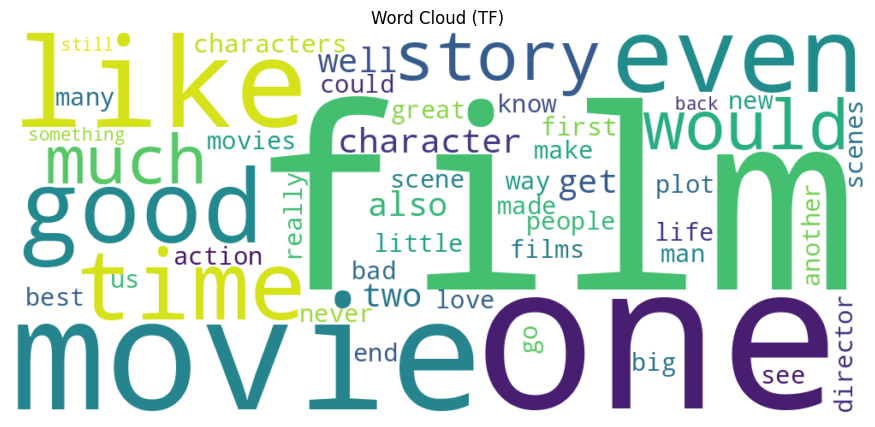

In [29]:

# ----------------------------
# 5) TF word cloud
# ----------------------------
tf_sums = np.asarray(review_dtm.sum(axis=0)).ravel()
freq_tf = dict(zip(cv_tf.get_feature_names_out(), tf_sums))

wc_tf = WordCloud(width=1000, height=450, background_color="white", max_words=50)
wc_tf.generate_from_frequencies(freq_tf)

plt.figure(figsize=(12, 5))
plt.imshow(wc_tf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (TF)")
plt.show()

## Word Cloud Visualization (Term Frequency)

A word cloud provides a quick visual summary of the most frequent words across all reviews.

In this visualization:
- Larger words appear more frequently
- Smaller words appear less frequently

This step helps build intuition about the dominant vocabulary in the dataset before modeling.


In [30]:
# ----------------------------
# 6) TF-IDF DTM (R: weighting = weightTfIdf) + removeSparseTerms(..., 0.95)
#    0.95 sparsity => keep terms appearing in >= 5% docs
# ----------------------------
tfidf_vec = TfidfVectorizer(min_df=0.05)
review_dtm_tfidf = tfidf_vec.fit_transform(corpus_clean)
print("\nTF-IDF DTM shape:", review_dtm_tfidf.shape)

# First doc: show 20 non-zero TF-IDF terms (similar to inspect)
terms_tfidf = np.array(tfidf_vec.get_feature_names_out())
row0_tfidf = review_dtm_tfidf[0].toarray().ravel()
nz_tfidf = row0_tfidf.nonzero()[0][:20]
print("\nFirst document: 20 non-zero TF-IDF terms")
display(pd.DataFrame({"term": terms_tfidf[nz_tfidf], "tfidf": row0_tfidf[nz_tfidf]}))




TF-IDF DTM shape: (2000, 990)

First document: 20 non-zero TF-IDF terms


,term,tfidf
0,actors,0.046729
1,actually,0.089387
2,ago,0.067957
3,also,0.032329
4,although,0.046388
5,always,0.049919
6,american,0.055070
7,apparently,0.134818
8,attempt,0.062967
9,audience,0.085317


## Word Cloud Visualization (TF–IDF)

The TF–IDF word cloud highlights **informative words**, not just frequent ones.

Compared to the TF word cloud:
- Generic terms are less prominent
- Sentiment-bearing or topic-specific words become more visible

This visualization helps confirm that TF–IDF is capturing meaningful language patterns.


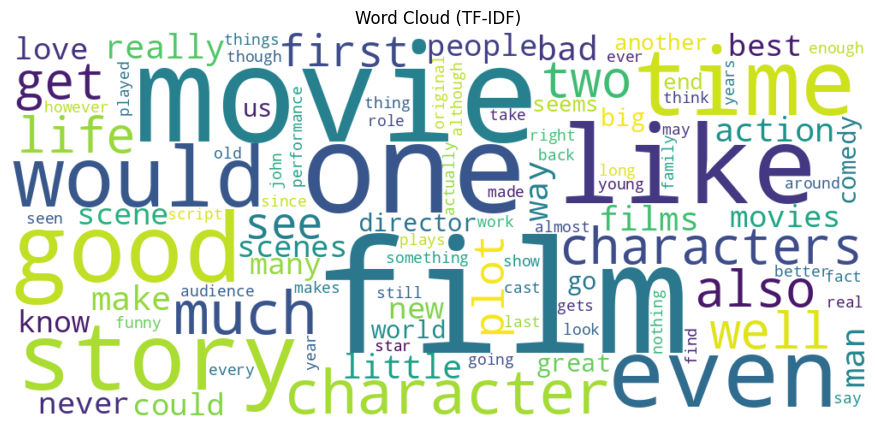

In [31]:
# ----------------------------
# 7) TF-IDF word cloud (R: colSums + wordcloud)
# ----------------------------
tfidf_sums = np.asarray(review_dtm_tfidf.sum(axis=0)).ravel()
freq_tfidf = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_sums))

wc_tfidf = WordCloud(width=1000, height=450, background_color="white", max_words=100)
wc_tfidf.generate_from_frequencies(freq_tfidf)

plt.figure(figsize=(12, 5))
plt.imshow(wc_tfidf, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (TF-IDF)")
plt.show()


## Sentiment Lexicon Features

In addition to TF–IDF features, we incorporate external sentiment knowledge.

Two curated word lists are loaded:
- A list of positive words
- A list of negative words

For each review, we count:
- How many positive words appear
- How many negative words appear

These counts create two interpretable features: `pos` and `neg`.


In [32]:
# ----------------------------
# 8) Load sentiment lexicons (R: read.table(...)[,1])
# ----------------------------
NEG_URL = "https://raw.githubusercontent.com/jonathanatuscpsu/DM-python/gh-pages/negative-words.txt"
POS_URL = "https://raw.githubusercontent.com/jonathanatuscpsu/DM-python/gh-pages/positive-words.txt"

def parse_wordlist(text: str) -> set:
    # remove blank lines + comments that start with ";"
    return set(
        line.strip()
        for line in text.splitlines()
        if line.strip() and not line.startswith(";")
    )

neg_words = parse_wordlist(requests.get(NEG_URL).text)
pos_words = parse_wordlist(requests.get(POS_URL).text)

print("\nLexicon sizes:")
print("  negative:", len(neg_words))
print("  positive:", len(pos_words))



Lexicon sizes:
  negative: 4783
  positive: 2006


## Feature Assembly and Train–Test Split

We combine:
- Lexicon-based sentiment features (`pos`, `neg`)
- TF–IDF text features

The combined feature matrix is then split into:
- 80% training data
- 20% testing data

This separation allows us to evaluate model performance on unseen reviews.


In [33]:
# ----------------------------
# 9) tm_term_score equivalent (count lexicon words per doc)
#    R:
#      reviews$neg = tm_term_score(DocumentTermMatrix(review_corpus), neg_words)
#      reviews$pos = tm_term_score(DocumentTermMatrix(review_corpus), pos_words)
# ----------------------------
def term_score(doc: str, lexicon: set) -> int:
    tokens = doc.split()
    return sum(t in lexicon for t in tokens)

reviews["neg"] = [term_score(d, neg_words) for d in corpus_clean]
reviews["pos"] = [term_score(d, pos_words) for d in corpus_clean]

print("\nNeg/Pos preview:")
display(reviews[["neg", "pos", TARGET_COL]].head())

print("\nNeg/Pos preview:")
display(reviews[["neg", "pos", TARGET_COL]].tail())


Neg/Pos preview:


,neg,pos,polarity
reviewid,,,
cv000_29416.txt,26,26,0
cv001_19502.txt,6,10,0
cv002_17424.txt,17,23,0
cv003_12683.txt,30,23,0
cv004_12641.txt,30,20,0



Neg/Pos preview:


,neg,pos,polarity
reviewid,,,
cv995_21821.txt,20,54,1
cv996_11592.txt,13,15,1
cv997_5046.txt,51,53,1
cv998_14111.txt,13,35,1
cv999_13106.txt,28,36,1


## 1.1 Predictive Modeling
We train four different classification models:

1. **Decision Tree**  
   - Rule-based and interpretable
2. **Logistic Regression**  
   - Linear probabilistic classifier
3. **Linear Support Vector Machine (SVM)**  
   - Strong baseline for text classification
4. **Neural Network**  
   - Nonlinear model with one hidden unit

Each model is trained using the same features for fair comparison.


In [34]:
# ----------------------------
# 10) Combine features for modeling
#     R:
#       reviews$content = NULL
#       reviews = cbind(reviews, as.matrix(review_dtm_tfidf))
#       reviews$polarity = as.factor(reviews$polarity)
# ----------------------------
y = reviews[TARGET_COL].astype(int).values

X_lex = reviews[["neg", "pos"]].values
X = hstack([csr_matrix(X_lex), review_dtm_tfidf]).tocsr()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)



In [35]:
# 11) Train models
# ----------------------------
def eval_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    err = np.mean(pred != y_test)

    print(f"\n{name}")
    print("Confusion matrix (Obs rows 0/1 x Pred cols 0/1):\n", cm)
    print("Test error rate:", err)
    return model

# Decision Tree (rpart)
tree = eval_model("Decision Tree", DecisionTreeClassifier(random_state=42))

# Logistic Regression (glm binomial)
glm = eval_model("Logistic Regression", LogisticRegression(max_iter=1000))

# SVM (for text, linear SVM is standard)
svm = eval_model("Linear SVM", LinearSVC())

# Neural Net (nnet size=1 ~ one hidden unit)
nnet = eval_model("Neural Net (1 hidden unit)", MLPClassifier(hidden_layer_sizes=(1,), max_iter=10000, random_state=42))



Decision Tree
Confusion matrix (Obs rows 0/1 x Pred cols 0/1):
 [[125  75]
 [ 72 128]]
Test error rate: 0.3675

Logistic Regression
Confusion matrix (Obs rows 0/1 x Pred cols 0/1):
 [[168  32]
 [ 44 156]]
Test error rate: 0.19

Linear SVM
Confusion matrix (Obs rows 0/1 x Pred cols 0/1):
 [[174  26]
 [ 38 162]]
Test error rate: 0.16

Neural Net (1 hidden unit)
Confusion matrix (Obs rows 0/1 x Pred cols 0/1):
 [[160  40]
 [ 34 166]]
Test error rate: 0.185


## Model Evaluation and Visualization

Model performance is evaluated using:

- **Confusion matrices**, showing correct and incorrect predictions
- **Test error rate**, defined as the fraction of misclassified reviews

Visual summaries allow us to compare models side-by-side and identify the best performer.


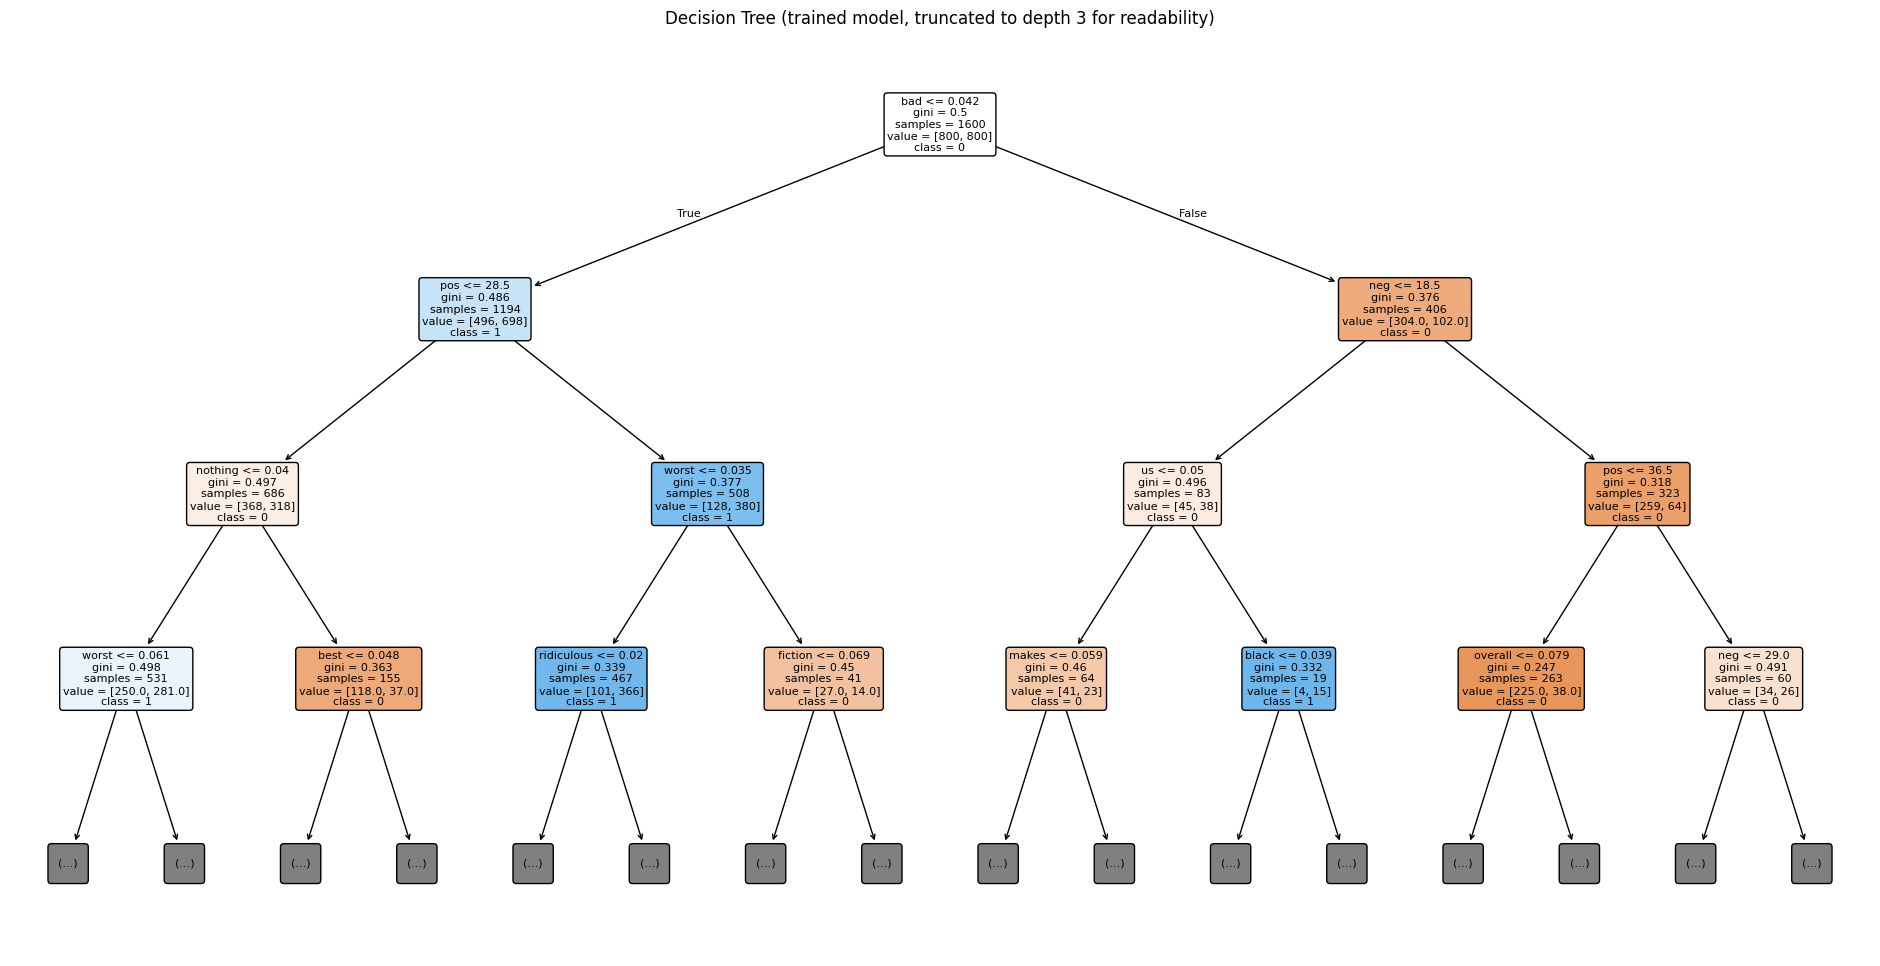

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=(["neg", "pos"] + list(tfidf_vec.get_feature_names_out())),
    class_names=["0", "1"],
    max_depth=3,   # keep small even if tree is deeper; set None to draw all (usually unreadable)
    fontsize=8
)
plt.title("Decision Tree (trained model, truncated to depth 3 for readability)")
plt.show()


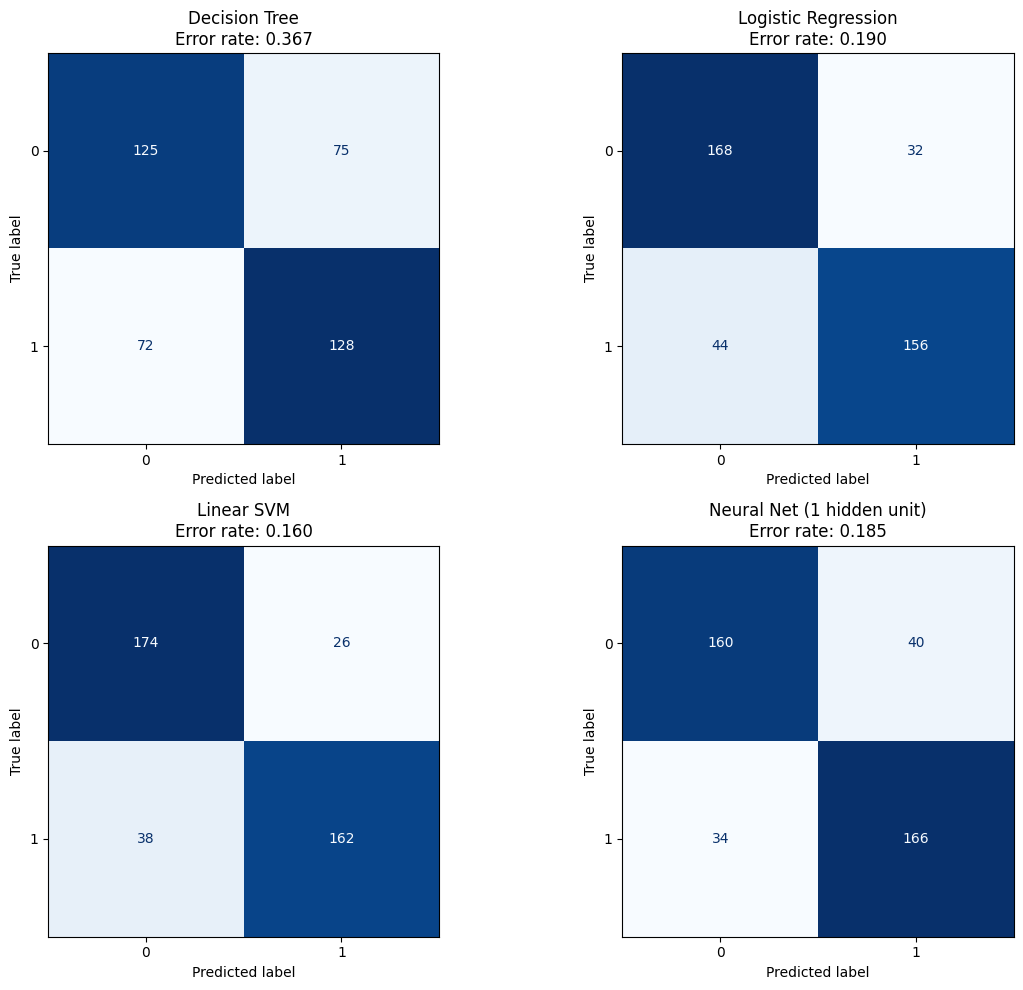

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Decision Tree": tree,
    "Logistic Regression": glm,
    "Linear SVM": svm,
    "Neural Net (1 hidden unit)": nnet
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["0", "1"], cmap="Blues", ax=ax, colorbar=False
    )
    err = (pred != y_test).mean()
    ax.set_title(f"{name}\nError rate: {err:.3f}")

plt.tight_layout()
plt.show()


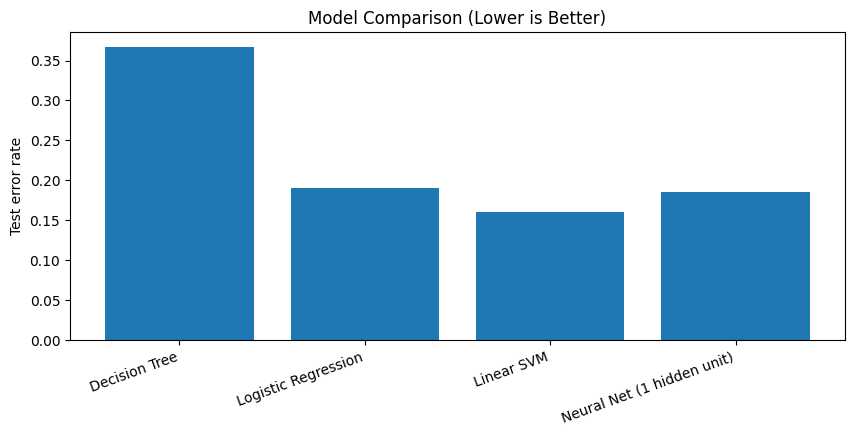

,model,test_error_rate
2,Linear SVM,0.1600
3,Neural Net (1 hidden unit),0.1850
1,Logistic Regression,0.1900
0,Decision Tree,0.3675


In [38]:
errs = {}
for name, model in models.items():
    pred = model.predict(X_test)
    errs[name] = (pred != y_test).mean()

plt.figure(figsize=(10, 4))
plt.bar(list(errs.keys()), list(errs.values()))
plt.xticks(rotation=20, ha="right")
plt.ylabel("Test error rate")
plt.title("Model Comparison (Lower is Better)")
plt.show()

pd.DataFrame({"model": list(errs.keys()), "test_error_rate": list(errs.values())}).sort_values("test_error_rate")


In [39]:
#Tree feature importances (top 20)

feature_names = ["neg", "pos"] + list(tfidf_vec.get_feature_names_out())
imp = tree.feature_importances_
top = np.argsort(imp)[::-1][:20]

pd.DataFrame({
    "feature": np.array(feature_names)[top],
    "importance": imp[top]
})


,feature,importance
0,pos,0.100016
1,bad,0.084173
2,worst,0.035350
3,nothing,0.025309
4,neg,0.023442
5,looks,0.017854
6,excellent,0.017799
7,reality,0.012192
8,script,0.012098
9,jokes,0.011915


In [40]:
#Logistic Regression coefficients (top + and top -)
coef = glm.coef_.ravel()
top_pos = np.argsort(coef)[::-1][:15]
top_neg = np.argsort(coef)[:15]

print("Top positive predictors (push toward class 1):")
display(pd.DataFrame({"feature": np.array(feature_names)[top_pos], "coef": coef[top_pos]}))

print("Top negative predictors (push toward class 0):")
display(pd.DataFrame({"feature": np.array(feature_names)[top_neg], "coef": coef[top_neg]}))


Top positive predictors (push toward class 1):


,feature,coef
0,horror,1.496340
1,war,1.474539
2,also,1.451987
3,hilarious,1.422833
4,dark,1.385251
5,overall,1.333285
6,life,1.253905
7,true,1.235644
8,excellent,1.115736
9,seen,1.112539


Top negative predictors (push toward class 0):


,feature,coef
0,bad,-2.867689
1,script,-1.810216
2,worst,-1.785599
3,better,-1.765106
4,nothing,-1.710154
5,supposed,-1.602824
6,looks,-1.561679
7,boring,-1.536900
8,like,-1.531051
9,unfortunately,-1.479726


## Model Interpretation

Beyond accuracy, we examine what the models learn:

- **Decision Tree feature importance** reveals which features drive early splits
- **Logistic Regression coefficients** show which words push predictions toward positive or negative sentiment

These tools help translate model output into human-interpretable insights.


In [41]:
!jupyter nbconvert --to html /content/12_Basic_Text_Mining.ipynb

[NbConvertApp] Converting notebook /content/12_Basic_Text_Mining.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1254950 bytes to /content/12_Basic_Text_Mining.html
